# Portfolio problem

In [1]:
import math
from pathlib import Path
# import cvxpy as cp
import numpy as np
import pandas as pd
# import scipy as sp
import matplotlib.pyplot as plt
import pickle

from mis_dro.dataset import get_portfolio_returns_df, get_window_of_train_and_test_dataframes
from mis_dro.experiments import ExperimentName
from mis_dro.constants import IN_SAMPLE_TIME_WINDOW, OUT_OF_SAMPLE_TIME_WINDOW
from mis_dro.plot import *
from mis_dro.portfolio import portfolio_objective_cvxpy
from mis_dro.preprocessing import normalise_by_dimension

from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":14})
rc('text', usetex=False)

from datetime import datetime

In [2]:
# TODO: refactor things a bit

compare_with_original = False
james_windows = True
include_transaction_costs = True
use_markowitz_development_script = False    # TODO: set to False outside of testing

if compare_with_original:
    james_windows = False
    include_transaction_costs = False

In [3]:
# kl_experiment_dir_string = "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025"
kl_experiment_dir_string = "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot"
# kl_experiment_dir_string = "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2025-filtration-interpolation"
# kl_experiment_dir_string = "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2016"
# kl_experiment_dir_string = "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio-repeat-parrot"

if compare_with_original:
    kl_experiment_dir_string = "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio-repeat-parrot"

kl_experiment_dir = Path(kl_experiment_dir_string)
assert kl_experiment_dir.exists()

mmc2_dir = Path("/", "dcs", "pg24", "u5674159", "datasets", "misdro", "mmc2")
assert mmc2_dir.exists()

# mmd_experiment_dir = Path("/dcs/large/u1508153/misdro/mmd_portfolio_debug/2025_01_17_normalise")
# assert mmd_experiment_dir.exists()

if james_windows:

    # TODO: move other data files into james-data
    experiment_dir_data_dir_map = {
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2016": '/dcs/pg24/u5674159/own-djia-data/_windows_19971001_to_20160427_inclusive_every_12_weeks.pkl',
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2025": '/dcs/pg24/u5674159/own-djia-data/_windows_19971001_to_20250730_inclusive_every_4_weeks.pkl',
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2025-filtration-interpolation": "/dcs/pg24/u5674159/own-djia-data/windows_19971001_to_20250702_inclusive_every_4_weeks.pkl",
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025": "/dcs/pg24/u5674159/mis-dro-code/james-data/windows_rebalance_dates_20080220_to_20250430_inclusive_every_13_weeks.pkl",
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot": "/dcs/pg24/u5674159/mis-dro-code/james-data/windows_rebalance_dates_20080220_to_20250430_inclusive_every_13_weeks.pkl"
    }

    experiment_dir_num_test_weeks_map = {
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2016": 12,
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2025": 4,
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2025-filtration-interpolation": 4,
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025": 13,
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot": 13
    }

    experiment_dir_benchmark_from_price_weighted_portfolio_weightings_map = {
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025": "/dcs/pg24/u5674159/mis-dro-code/james-data/windows_rebalance_dates_20080220_to_20250430_inclusive_every_13_weeks_benchmark_for_price_weighted_portfolio_weightings.pkl",
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot": "/dcs/pg24/u5674159/mis-dro-code/james-data/windows_rebalance_dates_20080220_to_20250430_inclusive_every_13_weeks_benchmark_for_price_weighted_portfolio_weightings.pkl"
    }

    # TODO: move other data files into james-data
    # experiment_dir_djia_level_file_map = {
    #     "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2016": "/dcs/pg24/u5674159/own-djia-data/_djia_level_19971001_to_20250730.npy",
    #     "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2025": "/dcs/pg24/u5674159/own-djia-data/_djia_level_19971001_to_20250730.npy",
    #     "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2025-filtration-interpolation": "/dcs/pg24/u5674159/own-djia-data/djia_level_19971001_to_20250730.npy",
    #     "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025": "/dcs/pg24/u5674159/own-djia-data/djia_level_20080220_to_20250730.npy",
    #     "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot": "/dcs/pg24/u5674159/own-djia-data/djia_level_20080220_to_20250730.npy"
    # }

    experiment_dir_markowitz_file_map = {
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025": "/dcs/pg24/u5674159/mis-dro-code/markowitz_results_james/results_for_multiple_lambdas.pkl",
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot": "/dcs/pg24/u5674159/mis-dro-code/markowitz_results_james/results_for_multiple_lambdas.pkl"
    }

    james_djia_data_path_string = experiment_dir_data_dir_map[kl_experiment_dir_string]
    james_djia_data_path = Path(james_djia_data_path_string)

    num_test_weeks = experiment_dir_num_test_weeks_map[kl_experiment_dir_string]

    james_benchmark_from_price_weighted_portfolio_weightings_map_file = experiment_dir_benchmark_from_price_weighted_portfolio_weightings_map[kl_experiment_dir_string]
    # james_djia_level_file = experiment_dir_djia_level_file_map[kl_experiment_dir_string]

    james_markowitz_results_file = experiment_dir_markowitz_file_map["/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025"]
    if use_markowitz_development_script:
        # TODO: maybe make another map for this
        james_markowitz_results_file = "/dcs/pg24/u5674159/mis-dro-code/markowitz_results_james/ipynb_results_for_multiple_lambdas.pkl"

    risk_free_rates_file = "/dcs/pg24/u5674159/mis-dro-code/james-data/risk_free_returns_weekly_2008-02-27_to_2025-07-30_inclusive.pkl"

In [4]:
def calculate_transaction_cost(
    prev_stock_figi_list: list[str],
    prev_portfolio_weighting: list,
    new_stock_figi_list: list[str],
    new_portfolio_weighting: list
) -> float:
    if len(prev_stock_figi_list) != len(prev_portfolio_weighting):
        raise ValueError("prev_stock_figi_list and prev_portfolio_weighting must be same length.")
    if len(new_stock_figi_list) != len(new_portfolio_weighting):
        raise ValueError("new_stock_figi_list and new_portfolio_weighting must be same length.")
    prev_map = {figi: float(w) for figi, w in zip(prev_stock_figi_list, prev_portfolio_weighting)}
    new_map  = {figi: float(w) for figi, w in zip(new_stock_figi_list,  new_portfolio_weighting)}
    all_figis = set(prev_map) | set(new_map)
    return 0.005 * sum(abs(new_map.get(figi, 0.0) - prev_map.get(figi, 0.0)) for figi in all_figis)

In [5]:
dgp = "DowJones"

if james_windows:
    with open(james_benchmark_from_price_weighted_portfolio_weightings_map_file, 'rb') as f:
        benchmark = pickle.load(f)
    prev_stock_figi_list = []
    prev_portfolio_weighting = []
    out_of_sample_costs = []
    for i, window in enumerate(benchmark):
        out_of_sample_costs_for_this_window = window["out_of_sample_cost"]
        if include_transaction_costs:
            weighting = window["weighting"]
            stock_figi_list = [col.split("_")[0] for col in weighting.index]
            transaction_cost = calculate_transaction_cost(prev_stock_figi_list, prev_portfolio_weighting, stock_figi_list, weighting)
            prev_stock_figi_list, prev_portfolio_weighting = stock_figi_list, weighting
            out_of_sample_costs_for_this_window.iloc[0] -= transaction_cost
        out_of_sample_costs += list(out_of_sample_costs_for_this_window)
    index_returns_np = np.array(out_of_sample_costs)
    index_returns_df = pd.DataFrame(index_returns_np)
else:
    index_returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Index_Returns", header=None)

if james_windows:
    with open(james_djia_data_path, 'rb') as f:
        windows = pickle.load(f)
else:
    returns_df = get_portfolio_returns_df(mmc2_dir, dgp)

if james_windows:
    with open(risk_free_rates_file, "rb") as f:
        risk_free_rates = pickle.load(f)

In [6]:
if james_windows:
    experiment_name = ExperimentName.kl_portfolio_james
else:
    experiment_name = ExperimentName.kl_portfolio
    print(experiment_name.value)
    
kl_results_df = pd.read_csv(kl_experiment_dir / "results.csv", index_col=["uuid", "replication"])


# mmd_results_df = pd.read_csv(mmd_experiment_dir / "results.csv", index_col=["uuid", "replication"])

all_results_df = kl_results_df.loc[kl_results_df["algorithm"].isin(["kl_dro_bas", "kl_pp", "kl_bdro"])]
# all_results_df = pd.concat([kl_results_df, mmd_results_df])

all_results_df["algorithm"].unique()

array(['kl_dro_bas', 'kl_bdro', 'kl_pp'], dtype=object)

In [7]:
# NOTE filter by DGP
if james_windows:
    filter_dgp = "james"
    dataset = "james"
else:
    filter_dgp = "DowJones"
    dataset = "portfolio"

results_df = preprocess_results_df(all_results_df, filter_dgp, dataset=dataset)

# NOTE filter out when log_partition_constant G is less than epsilon
# results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]

# NOTE we always want the same number of test observations and replications
assert np.isclose(results_df["num_test_observations"].var(), 0)
num_test_observations = results_df["num_test_observations"].unique()[0]
assert np.isclose(results_df["num_replications"].var(), 0)
num_replications = results_df["num_replications"].unique()[0]

# NOTE if you are running PP with multiple num_likelihood_samples then you will need the below line
results_df = results_df.loc[((results_df["algorithm"] == "kl_pp") & (results_df["num_likelihood_samples"] == 3600)) | (results_df["algorithm"] != "kl_pp")]

In [8]:
agg_df = get_agg_df(results_df, ["algorithm", "epsilon", "inference"])
agg_df

/dcs/pg24/u5674159/mis-dro-code/mis_dro/plot.py:216: FutureWarning: The provided callable <function mean at 0x7f94e06f5080> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg24/u5674159/mis-dro-code/mis_dro/plot.py:216: FutureWarning: The provided callable <function std at 0x7f94e06f51c0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


out_of_sample_mean  out_of_sample_var  \
algorithm  epsilon inference                                          
kl_bdro    0.00001 bayes                0.002660           0.001121   
           0.00002 bayes                0.002616           0.001073   
           0.00005 bayes                0.002579           0.000965   
           0.00010 bayes                0.002457           0.000858   
           0.00020 bayes                0.002289           0.000747   
           0.00050 bayes                0.002093           0.000628   
           0.00100 bayes                0.002102           0.000552   
           0.00200 bayes                0.002086           0.000498   
           0.00500 bayes                0.002097           0.000451   
           0.01000 bayes                0.002090           0.000436   
           0.02000 bayes                0.002079           0.000433   
           0.05000 bayes                0.002059           0.000436   
           0.10000 bayes                0.002046           0.000440   
           0.20000 bayes                0.002033           0.000443   
           0.50000 bayes                0.002018           0.000448   
           1.00000 bayes                0.002009           0.000450   
kl_dro_bas 0.00001 bayes                0.002668           0.001135   
           0.00002 bayes                0.002644           0.001108   
           0.00005 bayes                0.002597           0.001027   
           0.00010 bayes                0.002535           0.000930   
           0.00020 bayes                0.002376           0.000818   
           0.00050 bayes                0.002176           0.000679   
           0.00100 bayes                0.002094           0.000601   
           0.00200 bayes                0.002088           0.000529   
           0.00500 bayes                0.002101           0.000470   
           0.01000 bayes                0.002093           0.000443   
           0.02000 bayes                0.002089           0.000433   
           0.05000 bayes                0.002071           0.000434   
           0.10000 bayes                0.002056           0.000437   
           0.20000 bayes                0.002044           0.000441   
           0.50000 bayes                0.002027           0.000446   
           1.00000 bayes                0.002017           0.000449   
kl_pp      0.00001 bayes                0.003367           0.001024   
           0.00002 bayes                0.003319           0.000993   
           0.00005 bayes                0.003187           0.000923   
           0.00010 bayes                0.003155           0.000846   
           0.00020 bayes                0.003085           0.000772   
           0.00050 bayes                0.002818           0.000687   
           0.00100 bayes                0.002636           0.000615   
           0.00200 bayes                0.002454           0.000553   
           0.00500 bayes                0.002275           0.000490   
           0.01000 bayes                0.002173           0.000464   
           0.02000 bayes                0.002121           0.000449   
           0.05000 bayes                0.002095           0.000441   
           0.10000 bayes                0.002071           0.000442   
           0.20000 bayes                0.002049           0.000444   
           0.50000 bayes                0.002020           0.000447   
           1.00000 bayes                0.001998           0.000449   

                              sum_of_in_group_var  var_of_in_group_mean  \
algorithm  epsilon inference                                              
kl_bdro    0.00001 bayes                 0.001062              0.000059   
           0.00002 bayes                 0.001018              0.000055   
           0.00005 bayes                 0.000916              0.000049   
           0.00010 bayes                 0.000818              0.000040   
           0.00020 bayes     

In [9]:
if james_windows:
    with open(james_markowitz_results_file, "rb") as f:
        markowitz_results_james = pickle.load(f)

/tmp/dcs-tmp.u5674159/ipykernel_3107311/941307135.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were

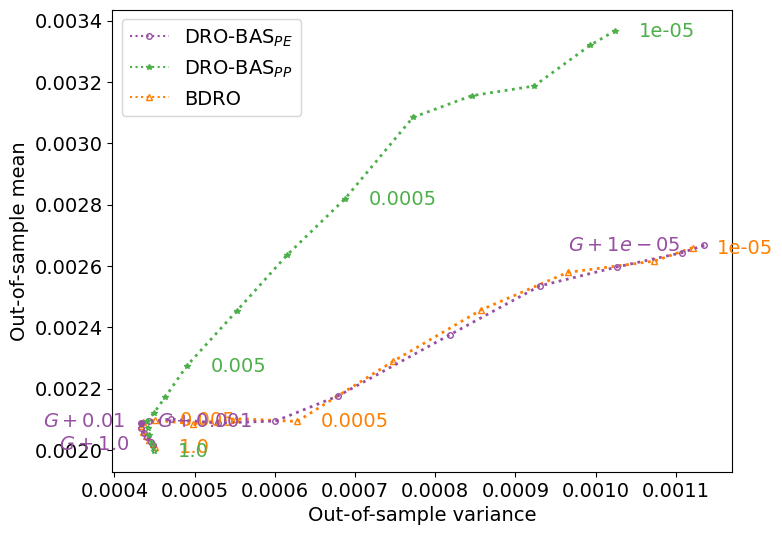

In [10]:
fig, ax = plt.subplots(figsize=(8,6))
df = agg_df
df.loc[:, "is_pareto_front"] = is_maximise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
for (algorithm, inference), group_df in df.groupby(["algorithm", "inference"]):
    if algorithm == "kl_dro_bas":
        local_log_partition_constant = True
        offset=0.00003
        special_epsilons = [0.00001, 0.001, 0.01, 1.0]
    else:
        local_log_partition_constant = False
        offset=0.00003
        special_epsilons = [0.00001, 0.0005, 0.005, 1.0]
    mean_variance_plot(
        ax, group_df, is_labelled=True, offset=offset, alpha=1.0,
        **algorithm_inference_style(algorithm, inference, label_inference=False),
        special_epsilons=special_epsilons,
        add_log_partition_function=local_log_partition_constant, minimise=False
    )
    #  log_partition_constant=local_log_partition_constant
# handles, labels = ax.get_legend_handles_labels()
# order = [1,0]
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
ax.legend(fontsize=12)
ax.set_xlabel("Out-of-sample variance")
ax.set_ylabel("Out-of-sample mean")
# ax.set_xlim(agg_df["out_of_sample_var"].min(), agg_df["out_of_sample_var"].max())
# ax.set_ylim(agg_df["out_of_sample_mean"].min(), agg_df["out_of_sample_mean"].min())
handles, labels = ax.get_legend_handles_labels()
algorithm_order = [AlgorithmName.kl_dro_bas.value, AlgorithmName.kl_pp.value, AlgorithmName.kl_bdro.value]
order = [list(labels).index(a) for a in algorithm_order]
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
fig.show()
# NOTE: this does not include transaction costs
# fig.savefig(f"{kl_experiment_dir_string}/{experiment_name}_mean_var_{filter_dgp}_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pdf", bbox_inches="tight")

In [11]:
if compare_with_original:

    mean_variance_plot_data_dict = {}
    current_label = None
    lines = ax.get_lines()
    for i in range(len(lines)):
        line = lines[i]
        label = line.get_label()
        if label != "_nolegend_":
            current_label = label
        elif i == len(lines) - 1 or lines[i + 1].get_label() != "_nolegend_":
            x, y = line.get_xdata(), line.get_ydata()
            mean_variance_plot_data_dict[current_label] = {"x": x, "y": y}

    directory_with_old_plot_data_for_replication = "/dcs/pg24/u5674159/mis-dro-code/james_old_plot_data_for_replication"
    with open(f"{directory_with_old_plot_data_for_replication}/mean_variance_bdro_dro-bas_real_data.pkl", "rb") as f:
        old_mean_variance_plot_data_dict = pickle.load(f)

    assert old_mean_variance_plot_data_dict.keys() == mean_variance_plot_data_dict.keys()
    for key in old_mean_variance_plot_data_dict:
        for coord in "x", "y":
            np.array_equal(old_mean_variance_plot_data_dict[key][coord], mean_variance_plot_data_dict[key][coord])

In [12]:
def get_weekly_values_in_period(weekly_values: list[float], period_in_weeks: int):
    return np.array(weekly_values[-period_in_weeks:])

def calculate_ratio(numerator, denominator):
    assert denominator != 0
    return numerator / denominator

def calculate_sharpe_ratio(weekly_portfolio_returns: list[float], weekly_risk_free_rates: list[float], period_in_weeks: int):
    weekly_portfolio_returns_in_period = get_weekly_values_in_period(weekly_portfolio_returns, period_in_weeks)
    weekly_risk_free_rates_in_period = get_weekly_values_in_period(weekly_risk_free_rates, period_in_weeks)
    weekly_excess_portfolio_returns_in_period = weekly_portfolio_returns_in_period - weekly_risk_free_rates_in_period
    numerator = np.mean(weekly_excess_portfolio_returns_in_period)
    denominator = np.std(weekly_excess_portfolio_returns_in_period) # TODO: note that population std is in use
    return calculate_ratio(numerator, denominator)

def calculate_sortino_ratio(weekly_portfolio_returns: list[float], weekly_targets: list[float], period_in_weeks: int):
    weekly_portfolio_returns_in_period = get_weekly_values_in_period(weekly_portfolio_returns, period_in_weeks)
    weekly_targets_in_period = get_weekly_values_in_period(weekly_targets, period_in_weeks)
    weekly_excess_portfolio_returns_in_period = weekly_portfolio_returns_in_period - weekly_targets_in_period
    numerator = np.mean(weekly_excess_portfolio_returns_in_period)
    weekly_downside_excess_portfolio_returns_in_period = np.minimum(0, weekly_excess_portfolio_returns_in_period)
    denominator = np.sqrt(np.mean(weekly_downside_excess_portfolio_returns_in_period ** 2))
    return calculate_ratio(numerator, denominator)

In [13]:
if james_windows:
    num_time_windows = len(windows)
else:
    num_time_windows = math.floor((len(returns_df) - IN_SAMPLE_TIME_WINDOW) / OUT_OF_SAMPLE_TIME_WINDOW)
    last_week = len(index_returns_df.iloc[IN_SAMPLE_TIME_WINDOW:])

kl_epsilon_list = [
    0.00001,
    0.001,
    1.0
]
mmd_epsilon_list = [0.0001, 0.01, 0.2]
kl_algorithms = ("kl_dro_bas", "kl_pp", "kl_bdro")

dro_algorithms_for_figure = (
    "kl_bdro",
    # "kl_pp",
    # "kl_dro_bas",
)

weeks_for_risk_adjusted_metrics = 156
rebalance_periods_for_risk_adjusted_metrics = int(weeks_for_risk_adjusted_metrics / num_test_weeks)

dro_figure_data = {algorithm: {} for algorithm in dro_algorithms_for_figure}

for (algorithm, epsilon), group_df in results_df.groupby(["algorithm", "epsilon"]):
    is_mmd_experiment = algorithm in ("dro_bas_mmd", "empirical_mmd")
    is_kl_experiment = algorithm in kl_algorithms

    if james_windows:
        if algorithm not in dro_algorithms_for_figure:
            continue

    if (is_kl_experiment and epsilon in kl_epsilon_list) or (is_mmd_experiment and epsilon in mmd_epsilon_list):
        cost_list = []
        sortino_ratios = []
        sharpe_ratios = []
        prev_stock_figi_list = []
        prev_portfolio_weighting = []
        for i in range(num_replications):
            out_of_sample_returns_this_period = group_df["out_of_sample_cost"].values[i]
            if include_transaction_costs:
                # TODO: this whole thing with the use of get_window_of_train_and_test_dataframes is a bit of a fudge--the stock IDs should be saved along with the other results. Moreover, I don't know why I appended _{window index} to each of the FIGIs in the first place, so undo that and get rid of the splitting done below.
                stock_figi_list = [col.split("_")[0] for col in get_window_of_train_and_test_dataframes(i, james_djia_data_path_string)[0].columns]
                portfolio_weighting = group_df["solution"].values[i]
                transaction_cost = calculate_transaction_cost(prev_stock_figi_list, prev_portfolio_weighting, stock_figi_list, portfolio_weighting)
                prev_stock_figi_list, prev_portfolio_weighting = stock_figi_list, portfolio_weighting
                out_of_sample_returns_this_period[0] -= transaction_cost
            cost_list += out_of_sample_returns_this_period
            sharpe_ratios.append(calculate_sharpe_ratio(cost_list, risk_free_rates[:(i+1)*num_test_weeks], weeks_for_risk_adjusted_metrics))
            sortino_ratios.append(calculate_sortino_ratio(cost_list, risk_free_rates[:(i+1)*num_test_weeks], weeks_for_risk_adjusted_metrics))
        dro_returns = np.array(cost_list)

        results = {
            "sharpe_ratios": sharpe_ratios,
            "sortino_ratios": sortino_ratios,
            "dro_returns": dro_returns,
        }

        dro_figure_data[algorithm][epsilon] = results

/tmp/dcs-tmp.u5674159/ipykernel_3107311/357246913.py:178: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families wer

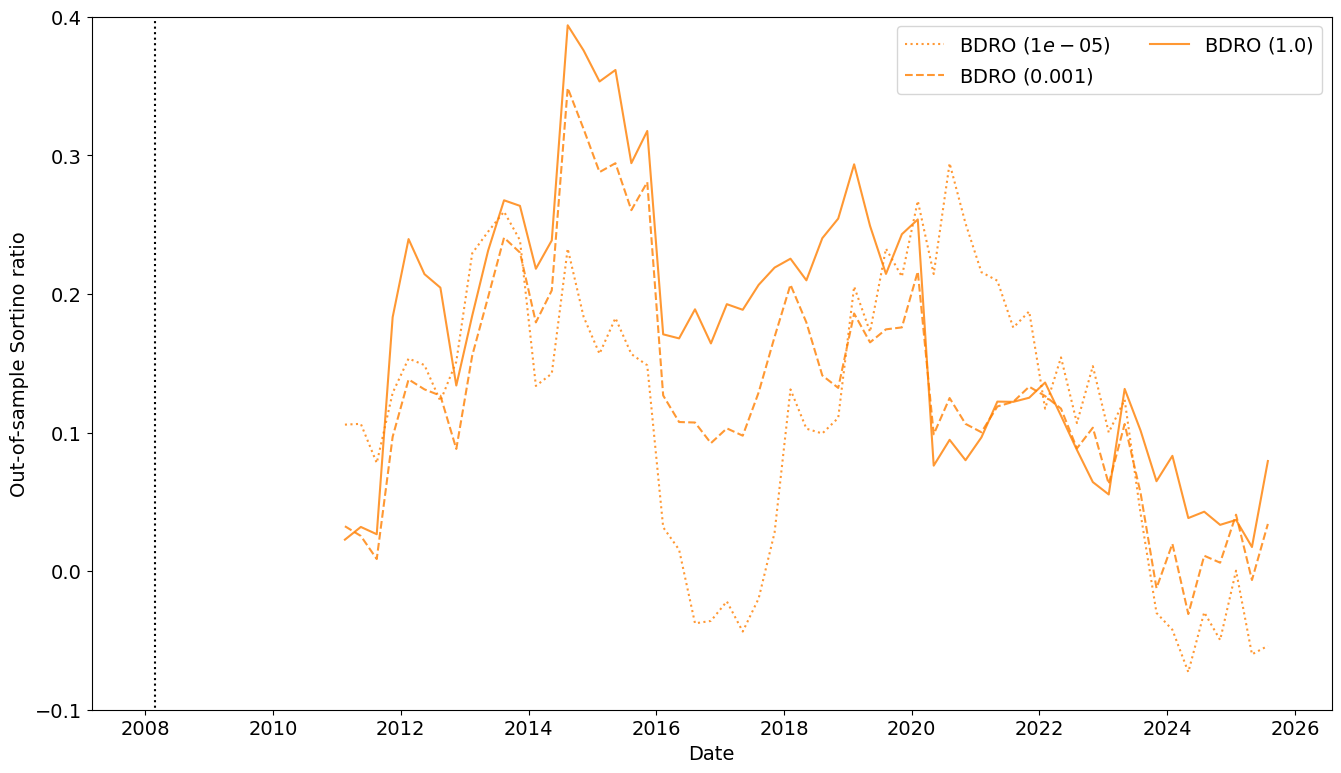

In [14]:
import datetime as dt

fig, ax = plt.subplots(figsize=(16,9))

if james_windows:
    start_date = dt.date(2008, 2, 27)   # NOTE: first test date
    end_date = dt.date(2025, 7, 30) # NOTE: last test date
    oos_weeks = []
    current = start_date
    while current <= end_date:
        oos_weeks.append(current)
        current += dt.timedelta(weeks=1)
else:
    oos_weeks = [IN_SAMPLE_TIME_WINDOW + i for i in range(OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows)]

# y_type = "cumulative return"
# y_type = "Sharpe ratio"
y_type = "Sortino ratio"

figure_name_addend = ""
if len(dro_algorithms_for_figure) == 1:
    figure_name_addend += "_" + dro_algorithms_for_figure[0]
if len(kl_epsilon_list) == 1:
    figure_name_addend += "_epsilon_" + str(kl_epsilon_list[0])
figure_name = f"{kl_experiment_dir_string}/{experiment_name}_{y_type.replace(' ', '_')}_{filter_dgp}{figure_name_addend}"

plot_markowitz = False
plot_price_weighted_benchmark = False

x_map = {
    "cumulative return": oos_weeks,
    "Sharpe ratio": oos_weeks[weeks_for_risk_adjusted_metrics-1 : : num_test_weeks],
    "Sortino ratio": oos_weeks[weeks_for_risk_adjusted_metrics-1 : : num_test_weeks],
}

for (algorithm, epsilon), group_df in results_df.groupby(["algorithm", "epsilon"]):
    is_mmd_experiment = algorithm in ("dro_bas_mmd", "empirical_mmd")
    is_kl_experiment = algorithm in kl_algorithms

    if james_windows:
        if algorithm not in dro_algorithms_for_figure:
            continue

    if (is_kl_experiment and epsilon in kl_epsilon_list) or (is_mmd_experiment and epsilon in mmd_epsilon_list):

        dro_returns = dro_figure_data[algorithm][epsilon]["dro_returns"]
        sharpe_ratios = dro_figure_data[algorithm][epsilon]["sharpe_ratios"]
        sortino_ratios = dro_figure_data[algorithm][epsilon]["sortino_ratios"]
        
        if algorithm == "kl_dro_bas":
            label = AlgorithmName[algorithm].value + " ($G +" + str(epsilon) + "$)"
        else:
            label = AlgorithmName[algorithm].value + f" (${epsilon}$)"
        is_robas_experiment = algorithm in ("dro_bas_mmd", "empirical_mmd")
        idx = mmd_epsilon_list.index(epsilon) if is_robas_experiment else kl_epsilon_list.index(epsilon)

        y_map = {
            "cumulative return": np.cumsum(dro_returns),
            "Sharpe ratio": sharpe_ratios[rebalance_periods_for_risk_adjusted_metrics-1:],
            "Sortino ratio": sortino_ratios[rebalance_periods_for_risk_adjusted_metrics-1:],
        }

        ax.plot(
            x_map[y_type],
            y_map[y_type],
            label=label,
            alpha=0.8,
            color=AlgorithmColor[algorithm].value,
            linestyle=["dotted" , "dashed" , "solid"][idx],
        )

CB_color_cycle = ['#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
if james_windows and plot_markowitz:

    markowitz_lambda_line_style_map = {
        0.5: "dotted",
        5: "dashdot",
        50: "dashed",
        500: "solid",
    }
    for item in markowitz_results_james.items():
        risk_aversion_value, windows = item
        if risk_aversion_value not in markowitz_lambda_line_style_map:
            continue
        markowitz_cost_list = []
        prev_stock_figi_list = []
        prev_portfolio_weighting = []
        markowitz_sharpe_ratios = []
        markowitz_sortino_ratios = []
        for i, window in enumerate(windows):
            out_of_sample_costs_for_window = list(window["out_of_sample_cost"])
            if include_transaction_costs:
                stock_figi_list = [col.split("_")[0] for col in get_window_of_train_and_test_dataframes(i, james_djia_data_path_string)[0].columns]
                portfolio_weighting = window["portfolio_weighting"]
                transaction_cost = calculate_transaction_cost(prev_stock_figi_list, prev_portfolio_weighting, stock_figi_list, portfolio_weighting)
                prev_stock_figi_list, prev_portfolio_weighting = stock_figi_list, portfolio_weighting
                out_of_sample_costs_for_window[0] -= transaction_cost
            markowitz_cost_list += out_of_sample_costs_for_window
            markowitz_sharpe_ratios.append(calculate_sharpe_ratio(markowitz_cost_list, risk_free_rates[:(i+1)*num_test_weeks], weeks_for_risk_adjusted_metrics))
            markowitz_sortino_ratios.append(calculate_sortino_ratio(markowitz_cost_list, risk_free_rates[:(i+1)*num_test_weeks], weeks_for_risk_adjusted_metrics))
        markowitz_returns = np.array(markowitz_cost_list)
        markowitz_label = f"Markowitz (λ = {risk_aversion_value})"

        y_map = {
            "cumulative return": np.cumsum(markowitz_returns),
            "Sharpe ratio": markowitz_sharpe_ratios[rebalance_periods_for_risk_adjusted_metrics-1:],
            "Sortino ratio": markowitz_sortino_ratios[rebalance_periods_for_risk_adjusted_metrics-1:]
        }

        ax.plot(
            x_map[y_type],
            y_map[y_type],
            label=markowitz_label,
            alpha=0.8,
            color="blue",
            linestyle=markowitz_lambda_line_style_map[risk_aversion_value]
        )

    if len(dro_algorithms_for_figure) == 0:
        figure_name = f"/dcs/pg24/u5674159/mis-dro-code/markowitz_results_james/markowitz_{y_type.replace(' ', '_')}"

if james_windows and plot_price_weighted_benchmark:

    index_returns_values_list = list(index_returns_df.values)
    sharpe_ratios = []
    sortino_ratios = []
    for i in range(num_time_windows):
        sharpe_ratios.append(calculate_sharpe_ratio(index_returns_values_list[:(i+1)*num_test_weeks], risk_free_rates[:(i+1)*num_test_weeks], weeks_for_risk_adjusted_metrics))
        sortino_ratios.append(calculate_sortino_ratio(index_returns_values_list[:(i+1)*num_test_weeks], risk_free_rates[:(i+1)*num_test_weeks], weeks_for_risk_adjusted_metrics))

    y_map = {
        "cumulative return": np.cumsum(index_returns_values_list),
        "Sharpe ratio": sharpe_ratios[rebalance_periods_for_risk_adjusted_metrics-1:],
        "Sortino ratio": sortino_ratios[rebalance_periods_for_risk_adjusted_metrics-1:]
    }

    ax.plot(
        x_map[y_type],
        y_map[y_type],
        label="DJIA Total Return Index",    # TODO: reconsider this might not be the best label, although you can always redefine it in the dissertation
        color="#a65628"
    )

if not james_windows:
    index_returns_axis = np.cumsum(index_returns_df.iloc[IN_SAMPLE_TIME_WINDOW: IN_SAMPLE_TIME_WINDOW + OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows].values)
    ax.plot(oos_weeks, index_returns_axis, label=f"{dgp} Index", color="#a65628")

if not james_windows:
    for i, baseline_model in enumerate(["MeanVar"]):
        baseline_model_label = baseline_model if baseline_model != "MeanVar" else "Markowitz"
        baseline_returns_txt = mmc2_dir / "Solutions" / dgp / f"OutofSamplePortReturns_{baseline_model}_{dgp}_List.txt" 
        baseline_portfolio_txt = mmc2_dir / "Solutions" / dgp / f"OptPortfolios_{baseline_model}_{dgp}.txt"
        baseline_portfolio = np.loadtxt(baseline_portfolio_txt).T[:num_time_windows, :]
        baseline_returns = np.loadtxt(baseline_returns_txt)
        ax.plot(oos_weeks, np.cumsum(baseline_returns[:OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows]), label=baseline_model_label, color=CB_color_cycle[i+1])

if james_windows:
    first_training_week = min(oos_weeks) - dt.timedelta(weeks=52)
    ax.set_xlim(first_training_week, max(oos_weeks) + dt.timedelta(weeks=52))
    ax.vlines(min(oos_weeks), -10, 10, color="black", linestyle=":")
    ax.set_xlabel("Date")
else:
    ax.vlines(52, -0.3, 4.6, color="black", linestyle=":")
    ax.set_xlabel("Week number")

figure_save_file = f"{figure_name}_"
if include_transaction_costs:
    figure_save_file += "transaction_costs_"
figure_save_file += f"{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pdf"

ylabel = f"Out-of-sample {y_type}"
ax.set_ylabel(ylabel)
ax.set_ylim(-0.1, 0.4)
ax.legend(ncol=2) 
# plt.savefig(figure_save_file, bbox_inches="tight")
fig.show()

In [15]:
if compare_with_original:

    cumulative_returns_plot_data_dict = {}

    for line in ax.get_lines():

        cumulative_returns_plot_data_dict[line.get_label()] = {
            "x": line.get_xdata(),
            "y": line.get_ydata()
        }

    directory_with_old_plot_data_for_replication = "/dcs/pg24/u5674159/mis-dro-code/james_old_plot_data_for_replication"
    with open(f"{directory_with_old_plot_data_for_replication}/cumulative_returns_bdro_dro-bas_real_data.pkl", "rb") as f:
        old_cumulative_returns_plot_data_dict = pickle.load(f)

    assert old_cumulative_returns_plot_data_dict.keys() == cumulative_returns_plot_data_dict.keys()
    for key in old_cumulative_returns_plot_data_dict:
        for coord in "x", "y":
            np.array_equal(old_cumulative_returns_plot_data_dict[key][coord], cumulative_returns_plot_data_dict[key][coord])

### James: NOTE: haven't adapted the below to kl_portfolio_james

In [16]:
# is_mmd_experiment = algorithm in ("dro_bas_mmd", "empirical_mmd")
# is_kl_experiment = algorithm in ("kl_dro_bas", "kl_pp", "kl_bdro", "kl_empirical")
# if (is_kl_experiment and epsilon in kl_epsilon_list) or (is_mmd_experiment and epsilon in mmd_epsilon_list):
row_list = []
for (algorithm, epsilon), group_df in results_df.loc[results_df["algorithm"].isin(kl_algorithms)].groupby(["algorithm", "epsilon"]):
    if (algorithm in kl_algorithms and epsilon in kl_epsilon_list) or (is_mmd_experiment and epsilon in mmd_epsilon_list):
        cost_list = []
        for i in range(num_replications):
            cost_list += group_df["out_of_sample_cost"].values[i]
        row_list.append({"cumulative_return": np.sum(cost_list), "epsilon": epsilon, "algorithm": algorithm})
cum_return_df = pd.DataFrame(row_list).set_index(["algorithm", "epsilon"])
cum_return_df = cum_return_df.reindex(pd.MultiIndex.from_arrays([np.repeat(kl_algorithms, len(kl_epsilon_list)), np.tile(kl_epsilon_list, len(kl_algorithms))], names=["algorithm", "epsilon"]))
# solve_time_df.reindex(pd.MultiIndex.from_product(np.repeat(["kl_dro_bas", "kl_pp", "kl_bdro", "kl_empirical"], 3), solve_time_df.index.get_level_values("num_total_samples"), names=['algorithm', 'num_total_samples']))
print(cum_return_df.unstack(level="algorithm").to_latex())
# cum_return_df

\begin{tabular}{lrrr}
\toprule
 & \multicolumn{3}{r}{cumulative_return} \\
algorithm & kl_bdro & kl_dro_bas & kl_pp \\
epsilon &  &  &  \\
\midrule
0.000010 & 2.023396 & 2.427426 & 3.064102 \\
0.001000 & 1.645432 & 1.905873 & 2.398928 \\
1.000000 & 1.784744 & 1.835773 & 1.817921 \\
\bottomrule
\end{tabular}



In [17]:
if james_windows:
    epsilon_filtered_results_df = results_df[results_df["epsilon"].isin(kl_epsilon_list)]

    solve_time_df = get_agg_df(
        epsilon_filtered_results_df,
        ["algorithm", "epsilon"]
    )[["mean_solve_time", "std_solve_time", "mean_sample_time", "std_sample_time"]]

    # print(solve_time_df)

    decimal_places = 3  # TODO: dynamically load this into the format strings below, if possible
    solve_time_df["str_sample_time"] = solve_time_df[["mean_sample_time", "std_sample_time"]].apply(
        lambda x: "{:.3f}".format(np.round(10**2 * x["mean_sample_time"], decimal_places)) + " (" + "{:.3f}".format(np.round(10**2 * x["std_sample_time"], decimal_places)) + ")", axis=1
    )

    solve_time_df["str_solve_time"] = solve_time_df[["mean_solve_time", "std_solve_time"]].apply(
        lambda x: "{:.3f}".format(np.round(x["mean_solve_time"], decimal_places)) + " (" + "{:.3f}".format(np.round(x["std_solve_time"], decimal_places)) + ")", axis=1
    )

    print(solve_time_df)

    solve_time_df = solve_time_df.reindex(["kl_dro_bas", "kl_pp", "kl_bdro", "kl_empirical"])
    solve_time_df.index = solve_time_df.index.map(lambda x: AlgorithmName[x].value)
    # print(solve_time_df[["str_solve_time", "str_sample_time"]].to_latex())

else:

    solve_time_df = get_agg_df(results_df, ["algorithm"])[["mean_solve_time", "std_solve_time", "mean_sample_time", "std_sample_time"]]

    decimal_places = 2
    solve_time_df["str_solve_time"] = solve_time_df[["mean_solve_time", "std_solve_time"]].apply(
        lambda x: "{:.2f}".format(np.round(x["mean_solve_time"], decimal_places)) + " (" + "{:.2f}".format(np.round(x["std_solve_time"], decimal_places)) + ")", axis=1
    )
    solve_time_df["str_sample_time"] = solve_time_df[["mean_sample_time", "std_sample_time"]].apply(
        lambda x: "{:.2f}".format(np.round(1000 * x["mean_sample_time"], decimal_places)) + " (" + "{:.2f}".format(np.round(1000 * x["std_sample_time"], decimal_places)) + ")", axis=1
    )
    solve_time_df = solve_time_df.reindex(["kl_dro_bas", "kl_pp", "kl_bdro", "kl_empirical"])
    solve_time_df.index = solve_time_df.index.map(lambda x: AlgorithmName[x].value)
    print(solve_time_df[["str_solve_time", "str_sample_time"]].to_latex())

/dcs/pg24/u5674159/mis-dro-code/mis_dro/plot.py:216: FutureWarning: The provided callable <function mean at 0x7f94e06f5080> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg24/u5674159/mis-dro-code/mis_dro/plot.py:216: FutureWarning: The provided callable <function std at 0x7f94e06f51c0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


                    mean_solve_time  std_solve_time  mean_sample_time  \
algorithm  epsilon                                                      
kl_bdro    0.00001         5.467449        0.346509          0.036447   
           0.00100         4.249667        0.757311          0.033443   
           1.00000         5.398451        0.335152          0.038207   
kl_dro_bas 0.00001         0.011781        0.020271          0.000452   
           0.00100         0.012072        0.002128          0.000910   
           1.00000         0.011046        0.002246          0.000830   
kl_pp      0.00001         2.455794        0.382296          0.003870   
           0.00100         2.225305        0.161835          0.004204   
           1.00000         1.424257        0.021123          0.003146   

                    std_sample_time str_sample_time str_solve_time  
algorithm  epsilon                                                  
kl_bdro    0.00001         0.004370   3.645 (0.437)  5.467

In [18]:
# bas_returns = []
# bdro_returns = []
# filter_epsilon = 0.1
# for (algorithm, epsilon), group_df in gb:
#     # dro_returns = group_df[week_cols].values.flatten()
#     if algorithm == "kl_dro_bas" and epsilon == filter_epsilon:
#         assert OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows == len(group_df) * len(group_df["out_of_sample_cost"].values[0])
#         for i in range(num_replications):
#             bas_returns += group_df["out_of_sample_cost"].values[i]
#     if algorithm == "kl_bdro" and epsilon == filter_epsilon:
#         assert OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows == len(group_df) * len(group_df["out_of_sample_cost"].values[0])
#         for i in range(num_replications):
#             bdro_returns += group_df["out_of_sample_cost"].values[i]
# plt.hist(bas_returns, bins=50, label="BAS", alpha=0.5)
# plt.hist(bdro_returns, bins=50, label="BDRO", alpha=0.5)
# plt.legend()

In [19]:
# from mis_dro.dataset import portfolio_dataset

# # training_time_window_id = 75
# training_time_window_id = 79
# out_of_sample_time_window = IN_SAMPLE_TIME_WINDOW
# data, data_eval = portfolio_dataset("DowJones-crash", training_time_window_id, mmc2_dir, out_of_sample_time_window=out_of_sample_time_window)
# dim = data.shape[1]
# sol = np.ones(dim) / float(dim)
# data.shape, data_eval.shape

In [20]:
start_training_week = training_time_window_id * OUT_OF_SAMPLE_TIME_WINDOW # inclusive
end_training_week = start_training_week + IN_SAMPLE_TIME_WINDOW # not inclusive
test_start = end_training_week
test_end = test_start + out_of_sample_time_window
total_training_returns = (data @ sol).sum()

plt.plot(oos_weeks[start_training_week- IN_SAMPLE_TIME_WINDOW:test_end - IN_SAMPLE_TIME_WINDOW], np.cumsum(index_returns_df.iloc[start_training_week:test_end].values), label=f"Out-of-sample {dgp} Index", color=CB_color_cycle[0], linestyle="dotted")
plt.plot(oos_weeks[start_training_week- IN_SAMPLE_TIME_WINDOW:test_start - IN_SAMPLE_TIME_WINDOW], np.cumsum(index_returns_df.iloc[start_training_week:test_start].values), label=f"In-sample {dgp} Index", color=CB_color_cycle[0])

# plt.plot(oos_weeks[start_training_week - IN_SAMPLE_TIME_WINDOW:end_training_week - IN_SAMPLE_TIME_WINDOW], (data @ sol).cumsum())
# plt.plot(oos_weeks[test_start - IN_SAMPLE_TIME_WINDOW:test_end - IN_SAMPLE_TIME_WINDOW], (data_eval @ sol).cumsum())
plt.legend()


NameError: name 'training_time_window_id' is not defined